# Task 3: Seq2Seq NMT with Hyperparameter Tuning and Real Embedding Experiments

This notebook implements the complete Task 3 workflow:

- 70/10/20 train-validation-test split
- LSTM encoder-decoder Seq2Seq model
- manual hyperparameter tuning selected only by validation loss
- fair embedding ablation: Random 100d vs GloVe 100d and Random 300d vs GloVe 300d
- English → Portuguese and Portuguese → English translation
- character-level English → Portuguese model
- BLEU and chrF evaluation
- sentence-length impact analysis

**Important:** `glove.6B` contains English embeddings. Therefore, GloVe is applied only to the English side of each translation direction. Portuguese embeddings remain randomly initialized and trainable.


## 1. Imports

In [1]:
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, asdict
from typing import List, Tuple, Optional
import random
import math
import time

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

## 2. Configuration

In [2]:
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "outputs_task2"
EN_PATH = DATA_DIR / "clean_sample_10_percent.en"
PT_PATH = DATA_DIR / "clean_sample_10_percent.pt"

OUTPUT_DIR = PROJECT_DIR / "outputs_task3_complete"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_DIR = PROJECT_DIR / "glove"
GLOVE_ZIP_PATH = GLOVE_DIR / "glove.6B.zip"
GLOVE_100_PATH = GLOVE_DIR / "glove.6B.100d.txt"
GLOVE_300_PATH = GLOVE_DIR / "glove.6B.300d.txt"

RANDOM_SEED = 42
# Set to None to use the complete 10% sample produced by Task 2.
# Keep 30000 for a faster first run on a laptop.
MAX_PAIRS = 30000
MAX_LEN_WORD = 50
MAX_LEN_CHAR = 250
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
CLIP = 1.0
TEACHER_FORCING_RATIO = 0.5

TUNING_EPOCHS = 2
FINAL_EPOCHS = 5
CHAR_EPOCHS = 3

PAD = "<pad>"
UNK = "<unk>"
SOS = "<sos>"
EOS = "<eos>"

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Project directory:", PROJECT_DIR)
print("EN file:", EN_PATH, EN_PATH.exists())
print("PT file:", PT_PATH, PT_PATH.exists())
print("Output directory:", OUTPUT_DIR)
print("Device:", DEVICE)


Project directory: /Users/baturu/Desktop/machine_translation
EN file: /Users/baturu/Desktop/machine_translation/outputs_task2/clean_sample_10_percent.en True
PT file: /Users/baturu/Desktop/machine_translation/outputs_task2/clean_sample_10_percent.pt True
Output directory: /Users/baturu/Desktop/machine_translation/outputs_task3_complete
Device: mps


## 3. Load preprocessed parallel data

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def read_lines(path: Path) -> List[str]:
    with open(path, "r", encoding="utf-8") as f:
        return [line.rstrip("\n") for line in f]

def load_pairs(en_path: Path, pt_path: Path) -> List[Tuple[str, str]]:
    en = read_lines(en_path)
    pt = read_lines(pt_path)
    assert len(en) == len(pt), "EN and PT files must have the same number of lines."
    return [(e, p) for e, p in zip(en, pt) if e.strip() and p.strip()]

set_seed(RANDOM_SEED)
pairs = load_pairs(EN_PATH, PT_PATH)
if MAX_PAIRS is not None:
    pairs = pairs[:MAX_PAIRS]

print("Loaded sentence pairs:", len(pairs))
print("EN example:", pairs[0][0])
print("PT example:", pairs[0][1])

Loaded sentence pairs: 30000
EN example: this is the obligation on the commission and it must implement the treaties.
PT example: essa é a obrigação da comissão, que tem de implementar os tratados.


## 4. Train / validation / test split

In [4]:
def split_pairs(pairs, test_ratio=0.20, val_ratio=0.10, seed=42):
    rng = random.Random(seed)
    pairs = pairs[:]
    rng.shuffle(pairs)
    n = len(pairs)
    n_test = int(test_ratio * n)
    n_val = int(val_ratio * n)
    test_pairs = pairs[:n_test]
    val_pairs = pairs[n_test:n_test+n_val]
    train_pairs = pairs[n_test+n_val:]
    return train_pairs, val_pairs, test_pairs

train_pairs, val_pairs, test_pairs = split_pairs(pairs, seed=RANDOM_SEED)

split_df = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "pairs": [len(train_pairs), len(val_pairs), len(test_pairs)],
    "ratio": [len(train_pairs)/len(pairs), len(val_pairs)/len(pairs), len(test_pairs)/len(pairs)]
})
display(split_df)
split_df.to_csv(OUTPUT_DIR / "split_statistics.csv", index=False)

,split,pairs,ratio
0,train,21000,0.7
1,validation,3000,0.1
2,test,6000,0.2


## 5. Tokenizers

In [5]:
def word_tokenize(text: str) -> List[str]:
    return text.strip().split()

def char_tokenize(text: str) -> List[str]:
    return list(text.strip())

print("Word tokens:", word_tokenize(train_pairs[0][0])[:20])
print("Char tokens:", char_tokenize(train_pairs[0][0])[:50])

Word tokens: ['it', 'would,', 'therefore,', 'not', 'surprise', 'me', 'if', 'certain', 'groupings,', 'including', 'in', 'this', 'parliament,', 'were', 'to', 'claim', 'that', 'this', 'agreement', 'does']
Char tokens: ['i', 't', ' ', 'w', 'o', 'u', 'l', 'd', ',', ' ', 't', 'h', 'e', 'r', 'e', 'f', 'o', 'r', 'e', ',', ' ', 'n', 'o', 't', ' ', 's', 'u', 'r', 'p', 'r', 'i', 's', 'e', ' ', 'm', 'e', ' ', 'i', 'f', ' ', 'c', 'e', 'r', 't', 'a', 'i', 'n', ' ', 'g', 'r']


## 6. Vocabulary class

In [6]:
class Vocab:
    def __init__(self, texts, tokenizer, max_size=None, min_freq=1):
        self.tokenizer = tokenizer
        self.specials = [PAD, UNK, SOS, EOS]
        counter = Counter()
        for text in texts:
            counter.update(tokenizer(text))
        tokens = []
        for tok, freq in counter.most_common():
            if freq < min_freq or tok in self.specials:
                continue
            tokens.append(tok)
            if max_size is not None and len(tokens) >= max_size - len(self.specials):
                break
        # itos: index to string
        self.itos = self.specials + tokens
        # stoi: string to index, e.g. "ai":7, "nlp":8
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}
        # 保存特殊符号的编号
        self.pad_idx = self.stoi[PAD]
        self.unk_idx = self.stoi[UNK]
        self.sos_idx = self.stoi[SOS]
        self.eos_idx = self.stoi[EOS]

    def __len__(self):
        return len(self.itos)

    def encode(self, text, add_sos_eos=True):
        ids = [self.stoi.get(tok, self.unk_idx) for tok in self.tokenizer(text)]
        if add_sos_eos:
            ids = [self.sos_idx] + ids + [self.eos_idx]
        return ids

    def decode(self, ids, remove_specials=True):
        tokens = []
        for idx in ids:
            tok = self.itos[idx] if 0 <= idx < len(self.itos) else UNK
            if remove_specials and tok in {PAD, SOS, EOS}:
                continue
            tokens.append(tok)
        return tokens

## 7. Dataset and DataLoader

In [7]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab, max_len, tokenizer_type="word"):
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_len = max_len
        self.tokenizer_type = tokenizer_type
        self.examples = []
        for src, trg in pairs:
            if tokenizer_type == "word":
                if len(word_tokenize(src)) > max_len or len(word_tokenize(trg)) > max_len:
                    continue
            else:
                if len(char_tokenize(src)) > max_len or len(char_tokenize(trg)) > max_len:
                    continue
            self.examples.append((src, trg))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        src, trg = self.examples[idx]
        return (
            torch.tensor(self.src_vocab.encode(src), dtype=torch.long),
            torch.tensor(self.trg_vocab.encode(trg), dtype=torch.long)
        )

def make_collate_fn(src_pad_idx, trg_pad_idx):
    def collate_fn(batch):
        src_batch, trg_batch = zip(*batch)
        max_src_len = max(len(x) for x in src_batch)
        max_trg_len = max(len(x) for x in trg_batch)
        padded_src = torch.full((len(batch), max_src_len), src_pad_idx, dtype=torch.long)
        padded_trg = torch.full((len(batch), max_trg_len), trg_pad_idx, dtype=torch.long)
        for i, (src, trg) in enumerate(zip(src_batch, trg_batch)):
            padded_src[i, :len(src)] = src
            padded_trg[i, :len(trg)] = trg
        return padded_src, padded_trg
    return collate_fn

## 8. Download and extract GloVe embeddings

Run this cell once. It downloads the official Stanford GloVe 6B archive and extracts only the 100d and 300d files used in the experiments.


In [8]:
import urllib.request
import zipfile

GLOVE_DIR.mkdir(parents=True, exist_ok=True)
required_glove_files = [GLOVE_100_PATH, GLOVE_300_PATH]

if not all(path.exists() for path in required_glove_files):
    if not GLOVE_ZIP_PATH.exists():
        print("Downloading GloVe 6B archive...")
        urllib.request.urlretrieve(
            "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip",
            GLOVE_ZIP_PATH,
        )
        print("Downloaded:", GLOVE_ZIP_PATH)

    with zipfile.ZipFile(GLOVE_ZIP_PATH, "r") as archive:
        for path in required_glove_files:
            if not path.exists():
                print("Extracting:", path.name)
                archive.extract(path.name, GLOVE_DIR)
else:
    print("Required GloVe files already exist.")

for path in required_glove_files:
    print(path.name, "exists:", path.exists())


Required GloVe files already exist.
glove.6B.100d.txt exists: True
glove.6B.300d.txt exists: True


## 9. GloVe embedding loader


In [9]:
def load_glove_vectors(glove_path: Path, expected_dim: int, vocab: Vocab):
    """Load vectors needed by a vocabulary and return matrix plus coverage statistics."""
    if not glove_path.exists():
        raise FileNotFoundError(
            f"Missing {glove_path}. Run the GloVe download cell before the experiments."
        )

    print("Loading:", glove_path)
    vocab_words = set(vocab.stoi)
    vectors = {}

    with open(glove_path, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            parts = line.rstrip().split()
            if len(parts) != expected_dim + 1:
                continue
            word = parts[0]
            if word in vocab_words:
                vectors[word] = torch.tensor(
                    [float(value) for value in parts[1:]], dtype=torch.float
                )

    matrix = torch.empty(len(vocab), expected_dim)
    nn.init.normal_(matrix, mean=0.0, std=0.1)
    matrix[vocab.pad_idx].zero_()

    special_tokens = {PAD, UNK, SOS, EOS}
    normal_words = [word for word in vocab.stoi if word not in special_tokens]
    covered_words = 0

    for word, index in vocab.stoi.items():
        vector = vectors.get(word)
        if vector is not None:
            matrix[index] = vector
            if word not in special_tokens:
                covered_words += 1

    coverage = covered_words / max(1, len(normal_words))
    print(
        f"Coverage excluding special tokens: {covered_words}/{len(normal_words)} "
        f"= {coverage * 100:.2f}%"
    )
    return matrix, coverage


## 10. RNN-based encoder-decoder Seq2Seq model

In [10]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout, pad_idx,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=pad_idx)
        if pretrained_embeddings is not None:
            assert pretrained_embeddings.shape == self.embedding.weight.data.shape
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = not freeze_embeddings
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)
        return hidden, cell

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout, pad_idx,
                 pretrained_embeddings=None, freeze_embeddings=False):
        super().__init__()
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_idx)
        if pretrained_embeddings is not None:
            assert pretrained_embeddings.shape == self.embedding.weight.data.shape
            self.embedding.weight.data.copy_(pretrained_embeddings)
            self.embedding.weight.requires_grad = not freeze_embeddings
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        hidden, cell = self.encoder(src)
        input_token = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = trg[:, t] if teacher_force else output.argmax(1)
        return outputs

## 11. Training and validation functions

In [11]:
def train_epoch(model, dataloader, optimizer, 
                criterion, clip, 
                teacher_forcing_ratio):
    model.train()
    epoch_loss = 0
    for src, trg in dataloader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / max(1, len(dataloader))

@torch.no_grad()
def evaluate_loss(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0
    for src, trg in dataloader:
        src = src.to(DEVICE)
        trg = trg.to(DEVICE)
        output = model(src, trg, teacher_forcing_ratio=0.0)
        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
        epoch_loss += loss.item()
    return epoch_loss / max(1, len(dataloader))

## 12. Translation, BLEU, and chrF

In [12]:
@torch.no_grad()
def translate_sentence(model, sentence, src_vocab, trg_vocab, max_output_len=80):
    model.eval()
    src_ids = src_vocab.encode(sentence)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    hidden, cell = model.encoder(src_tensor)
    input_token = torch.tensor([trg_vocab.sos_idx], dtype=torch.long).to(DEVICE)
    output_ids = []
    for _ in range(max_output_len):
        output, hidden, cell = model.decoder(input_token, hidden, cell)
        pred_id = output.argmax(1).item()
        if pred_id == trg_vocab.eos_idx:
            break
        output_ids.append(pred_id)
        input_token = torch.tensor([pred_id], dtype=torch.long).to(DEVICE)
    return trg_vocab.decode(output_ids)

def ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def corpus_bleu(references, hypotheses, max_n=4):
    clipped_counts = [0] * max_n
    total_counts = [0] * max_n
    ref_len = 0
    hyp_len = 0
    for ref, hyp in zip(references, hypotheses):
        ref_len += len(ref)
        hyp_len += len(hyp)
        for n in range(1, max_n + 1):
            ref_counts = Counter(ngrams(ref, n))
            hyp_counts = Counter(ngrams(hyp, n))
            total_counts[n-1] += sum(hyp_counts.values())
            for gram, count in hyp_counts.items():
                clipped_counts[n-1] += min(count, ref_counts.get(gram, 0))
    precisions = [(c + 1) / (t + 1) for c, t in zip(clipped_counts, total_counts)]
    if hyp_len == 0:
        return 0.0
    bp = 1.0 if hyp_len > ref_len else math.exp(1 - ref_len / max(1, hyp_len))
    return bp * math.exp(sum(math.log(p) for p in precisions) / max_n) * 100

def char_ngrams(text, n):
    return [text[i:i+n] for i in range(len(text)-n+1)]

def sentence_chrf(reference, hypothesis, max_n=6, beta=2.0):
    scores = []
    for n in range(1, max_n + 1):
        ref_counts = Counter(char_ngrams(reference, n))
        hyp_counts = Counter(char_ngrams(hypothesis, n))
        overlap = sum(min(count, ref_counts.get(g, 0)) for g, count in hyp_counts.items())
        precision = overlap / max(1, sum(hyp_counts.values()))
        recall = overlap / max(1, sum(ref_counts.values()))
        if precision == 0 and recall == 0:
            scores.append(0.0)
        else:
            scores.append((1 + beta**2) * precision * recall / (beta**2 * precision + recall))
    return sum(scores) / len(scores) * 100

def corpus_chrf(reference_texts, hypothesis_texts):
    return sum(sentence_chrf(r, h) for r, h in zip(reference_texts, hypothesis_texts)) / max(1, len(reference_texts))

@torch.no_grad()
def evaluate_translation_metrics(model, test_examples, src_vocab, trg_vocab, tokenizer_type="word", max_examples=500):
    eval_examples = test_examples[:max_examples]
    joiner = "" if tokenizer_type == "char" else " "
    references_tokens, hypotheses_tokens = [], []
    references_text, hypotheses_text = [], []
    max_output_len = 250 if tokenizer_type == "char" else 80
    for src, ref in eval_examples:
        hyp_tokens = translate_sentence(model, src, src_vocab, trg_vocab, max_output_len=max_output_len)
        ref_tokens = char_tokenize(ref) if tokenizer_type == "char" else word_tokenize(ref)
        references_tokens.append(ref_tokens)
        hypotheses_tokens.append(hyp_tokens)
        references_text.append(ref)
        hypotheses_text.append(joiner.join(hyp_tokens))
    return corpus_bleu(references_tokens, hypotheses_tokens), corpus_chrf(references_text, hypotheses_text), references_text, hypotheses_text

## 13. Experiment configuration and runner


In [13]:
@dataclass
class ExperimentConfig:
    name: str
    src_lang: str
    trg_lang: str
    tokenizer_type: str = "word"
    embedding_type: str = "random"  # random, glove100, glove300
    emb_dim: int = 256
    hid_dim: int = 512
    dropout: float = 0.3
    num_epochs: int = 5
    freeze_embeddings: bool = False


def make_direction_pairs(all_pairs, src_lang, trg_lang):
    if src_lang == "en" and trg_lang == "pt":
        return all_pairs
    if src_lang == "pt" and trg_lang == "en":
        return [(pt, en) for en, pt in all_pairs]
    raise ValueError("Only en→pt and pt→en are supported.")


def build_data_for_config(config, all_pairs):
    exp_pairs = make_direction_pairs(all_pairs, config.src_lang, config.trg_lang)
    train_p, val_p, test_p = split_pairs(exp_pairs, seed=RANDOM_SEED)
    tokenizer = word_tokenize if config.tokenizer_type == "word" else char_tokenize
    max_len = MAX_LEN_WORD if config.tokenizer_type == "word" else MAX_LEN_CHAR
    max_vocab = MAX_VOCAB_SIZE if config.tokenizer_type == "word" else None
    min_freq = MIN_FREQ if config.tokenizer_type == "word" else 1

    src_vocab = Vocab([src for src, _ in train_p], tokenizer, max_size=max_vocab, min_freq=min_freq)
    trg_vocab = Vocab([trg for _, trg in train_p], tokenizer, max_size=max_vocab, min_freq=min_freq)

    train_data = TranslationDataset(train_p, src_vocab, trg_vocab, max_len, config.tokenizer_type)
    val_data = TranslationDataset(val_p, src_vocab, trg_vocab, max_len, config.tokenizer_type)
    test_data = TranslationDataset(test_p, src_vocab, trg_vocab, max_len, config.tokenizer_type)

    collate_fn = make_collate_fn(src_vocab.pad_idx, trg_vocab.pad_idx)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    return src_vocab, trg_vocab, train_data, val_data, test_data, train_loader, val_loader


def get_embedding_matrices(config, src_vocab, trg_vocab):
    """Use English GloVe only on the English side; leave Portuguese random."""
    metadata = {"src_embedding_coverage": 0.0, "trg_embedding_coverage": 0.0}
    if config.embedding_type == "random":
        return None, None, metadata

    if config.embedding_type == "glove100":
        path, dim = GLOVE_100_PATH, 100
    elif config.embedding_type == "glove300":
        path, dim = GLOVE_300_PATH, 300
    else:
        raise ValueError(f"Unknown embedding type: {config.embedding_type}")

    if config.emb_dim != dim:
        raise ValueError(f"{config.embedding_type} requires emb_dim={dim}")

    src_matrix = trg_matrix = None
    if config.src_lang == "en":
        src_matrix, metadata["src_embedding_coverage"] = load_glove_vectors(path, dim, src_vocab)
    if config.trg_lang == "en":
        trg_matrix, metadata["trg_embedding_coverage"] = load_glove_vectors(path, dim, trg_vocab)

    return src_matrix, trg_matrix, metadata


def create_model_from_config(config, src_vocab, trg_vocab):
    src_matrix, trg_matrix, embedding_metadata = get_embedding_matrices(config, src_vocab, trg_vocab)
    encoder = Encoder(
        len(src_vocab), config.emb_dim, config.hid_dim, config.dropout, src_vocab.pad_idx,
        pretrained_embeddings=src_matrix, freeze_embeddings=config.freeze_embeddings,
    )
    decoder = Decoder(
        len(trg_vocab), config.emb_dim, config.hid_dim, config.dropout, trg_vocab.pad_idx,
        pretrained_embeddings=trg_matrix, freeze_embeddings=config.freeze_embeddings,
    )
    return Seq2Seq(encoder, decoder, DEVICE).to(DEVICE), embedding_metadata


def run_experiment(config, all_pairs, save_predictions=True, evaluate_test=True):
    print("\n" + "=" * 100)
    print(config)
    print("=" * 100)
    set_seed(RANDOM_SEED)

    src_vocab, trg_vocab, train_data, val_data, test_data, train_loader, val_loader = \
        build_data_for_config(config, all_pairs)
    print("src vocab:", len(src_vocab), "trg vocab:", len(trg_vocab))
    print("train:", len(train_data), "val:", len(val_data), "test:", len(test_data))

    model, embedding_metadata = create_model_from_config(config, src_vocab, trg_vocab)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=trg_vocab.pad_idx)

    history, best_val_loss = [], float("inf")
    best_path = OUTPUT_DIR / f"{config.name}_best.pt"

    for epoch in range(1, config.num_epochs + 1):
        start = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP, TEACHER_FORCING_RATIO)
        val_loss = evaluate_loss(model, val_loader, criterion)
        elapsed = time.time() - start
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_ppl": math.exp(min(train_loss, 20)),
            "val_ppl": math.exp(min(val_loss, 20)),
            "time_sec": elapsed,
        })
        print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | time {elapsed:.1f}s")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)
            print("Saved best model:", best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / f"{config.name}_history.csv", index=False)

    bleu = chrf = float("nan")
    refs, hyps = [], []
    prediction_path = ""
    if evaluate_test:
        bleu, chrf, refs, hyps = evaluate_translation_metrics(
            model, test_data.examples, src_vocab, trg_vocab,
            tokenizer_type=config.tokenizer_type,
        )
        if save_predictions:
            prediction_path = OUTPUT_DIR / f"{config.name}_sample_predictions.txt"
            with open(prediction_path, "w", encoding="utf-8") as file:
                for i, ((src, ref), hyp) in enumerate(zip(test_data.examples[:50], hyps[:50]), 1):
                    file.write(f"Example {i}\nSRC: {src}\nREF: {ref}\nHYP: {hyp}\n" + "-" * 80 + "\n")
        print("Test BLEU:", round(bleu, 2), "Test chrF:", round(chrf, 2))

    result = {
        **asdict(config),
        **embedding_metadata,
        "src_vocab_size": len(src_vocab),
        "trg_vocab_size": len(trg_vocab),
        "train_examples": len(train_data),
        "val_examples": len(val_data),
        "test_examples": len(test_data),
        "best_val_loss": best_val_loss,
        "test_bleu": bleu,
        "test_chrf": chrf,
        "best_model_path": str(best_path),
        "prediction_path": str(prediction_path),
    }
    return {
        "config": config, "model": model, "src_vocab": src_vocab,
        "trg_vocab": trg_vocab, "test_data": test_data,
        "history_df": history_df, "result": result,
    }


## 14. Manual hyperparameter tuning

In [14]:
tuning_configs = [
    ExperimentConfig("tune_random_small", "en", "pt", emb_dim=128, hid_dim=256, dropout=0.3, num_epochs=TUNING_EPOCHS),
    ExperimentConfig("tune_random_base", "en", "pt", emb_dim=256, hid_dim=512, dropout=0.3, num_epochs=TUNING_EPOCHS),
    ExperimentConfig("tune_random_base_dropout05", "en", "pt", emb_dim=256, hid_dim=512, dropout=0.5, num_epochs=TUNING_EPOCHS),
]

tuning_outputs = [
    run_experiment(config, pairs, save_predictions=False, evaluate_test=False)
    for config in tuning_configs
]
tuning_df = pd.DataFrame([output["result"] for output in tuning_outputs])
display(tuning_df[["name", "emb_dim", "hid_dim", "dropout", "best_val_loss"]])
tuning_df.to_csv(OUTPUT_DIR / "manual_hyperparameter_tuning_results.csv", index=False)

best_tuning_row = tuning_df.sort_values("best_val_loss").iloc[0]
print("Configuration selected only by lowest validation loss:")
display(best_tuning_row[["name", "emb_dim", "hid_dim", "dropout", "best_val_loss"]])



ExperimentConfig(name='tune_random_small', src_lang='en', trg_lang='pt', tokenizer_type='word', embedding_type='random', emb_dim=128, hid_dim=256, dropout=0.3, num_epochs=2, freeze_embeddings=False)
src vocab: 14457 trg vocab: 18693
train: 19424 val: 2785 test: 5555
Epoch 01 | train loss 6.8955 | val loss 6.5291 | time 442.1s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_complete/tune_random_small_best.pt
Epoch 02 | train loss 6.4346 | val loss 6.5139 | time 353.9s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_complete/tune_random_small_best.pt

ExperimentConfig(name='tune_random_base', src_lang='en', trg_lang='pt', tokenizer_type='word', embedding_type='random', emb_dim=256, hid_dim=512, dropout=0.3, num_epochs=2, freeze_embeddings=False)
src vocab: 14457 trg vocab: 18693
train: 19424 val: 2785 test: 5555
Epoch 01 | train loss 6.7699 | val loss 6.5403 | time 337.0s
Saved best model: /Users/baturu/Desktop/machine_translation/outp

,name,emb_dim,hid_dim,dropout,best_val_loss
0,tune_random_small,128,256,0.3,6.513939
1,tune_random_base,256,512,0.3,6.507777
2,tune_random_base_dropout05,256,512,0.5,6.539520


Configuration selected only by lowest validation loss:


name             tune_random_base
emb_dim                       256
hid_dim                       512
dropout                       0.3
best_val_loss            6.507777
Name: 1, dtype: object

## 15. Plot manual tuning results

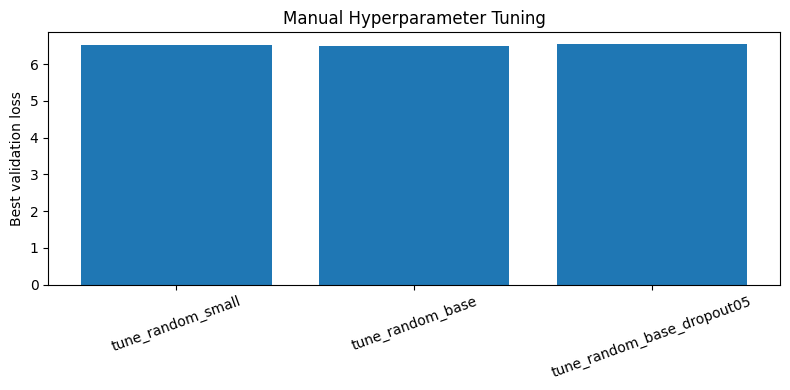

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(tuning_df["name"], tuning_df["best_val_loss"])
plt.ylabel("Best validation loss")
plt.title("Manual Hyperparameter Tuning")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "manual_tuning_val_loss.png", dpi=200)
plt.show()

## 16. Fair embedding comparison: Random vs GloVe at equal dimensions


In [16]:
best_hid_dim = int(best_tuning_row["hid_dim"])
best_dropout = float(best_tuning_row["dropout"])

embedding_configs = [
    ExperimentConfig(
        name="final_word_en_to_pt_random100",
        src_lang="en", trg_lang="pt", embedding_type="random",
        emb_dim=100, hid_dim=best_hid_dim, dropout=best_dropout,
        num_epochs=FINAL_EPOCHS,
    ),
    ExperimentConfig(
        name="final_word_en_to_pt_glove100",
        src_lang="en", trg_lang="pt", embedding_type="glove100",
        emb_dim=100, hid_dim=best_hid_dim, dropout=best_dropout,
        num_epochs=FINAL_EPOCHS, freeze_embeddings=False,
    ),
    ExperimentConfig(
        name="final_word_en_to_pt_random300",
        src_lang="en", trg_lang="pt", embedding_type="random",
        emb_dim=300, hid_dim=best_hid_dim, dropout=best_dropout,
        num_epochs=FINAL_EPOCHS,
    ),
    ExperimentConfig(
        name="final_word_en_to_pt_glove300",
        src_lang="en", trg_lang="pt", embedding_type="glove300",
        emb_dim=300, hid_dim=best_hid_dim, dropout=best_dropout,
        num_epochs=FINAL_EPOCHS, freeze_embeddings=False,
    ),
]

embedding_outputs = [
    run_experiment(config, pairs, save_predictions=True, evaluate_test=True)
    for config in embedding_configs
]

embedding_results_df = pd.DataFrame([output["result"] for output in embedding_outputs])
display(embedding_results_df[[
    "name", "embedding_type", "emb_dim", "src_embedding_coverage",
    "best_val_loss", "test_bleu", "test_chrf",
]])
embedding_results_df.to_csv(OUTPUT_DIR / "embedding_comparison_results.csv", index=False)

# Use random 100d as the primary word-level baseline for later comparisons.
final_random_output = embedding_outputs[0]
glove100_output = embedding_outputs[1]
random300_output = embedding_outputs[2]
glove300_output = embedding_outputs[3]



ExperimentConfig(name='final_word_en_to_pt_random100', src_lang='en', trg_lang='pt', tokenizer_type='word', embedding_type='random', emb_dim=100, hid_dim=512, dropout=0.3, num_epochs=5, freeze_embeddings=False)
src vocab: 14457 trg vocab: 18693
train: 19424 val: 2785 test: 5555
Epoch 01 | train loss 6.8258 | val loss 6.5234 | time 337.4s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_complete/final_word_en_to_pt_random100_best.pt
Epoch 02 | train loss 6.4158 | val loss 6.5333 | time 346.2s
Epoch 03 | train loss 6.2416 | val loss 6.5199 | time 358.2s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_complete/final_word_en_to_pt_random100_best.pt
Epoch 04 | train loss 6.1096 | val loss 6.5078 | time 342.7s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_complete/final_word_en_to_pt_random100_best.pt
Epoch 05 | train loss 5.9952 | val loss 6.4571 | time 320.6s
Saved best model: /Users/baturu/Desktop/machine_tran

,name,embedding_type,emb_dim,src_embedding_coverage,best_val_loss,test_bleu,test_chrf
0,final_word_en_to_pt_random100,random,100,0.000000,6.457129,0.175463,7.990387
1,final_word_en_to_pt_glove100,glove100,100,0.630181,6.353396,0.399098,12.928489
2,final_word_en_to_pt_random300,random,300,0.000000,6.340412,0.631275,9.826403
3,final_word_en_to_pt_glove300,glove300,300,0.630181,6.363624,0.473373,13.155343


## 17. Plot embedding comparison


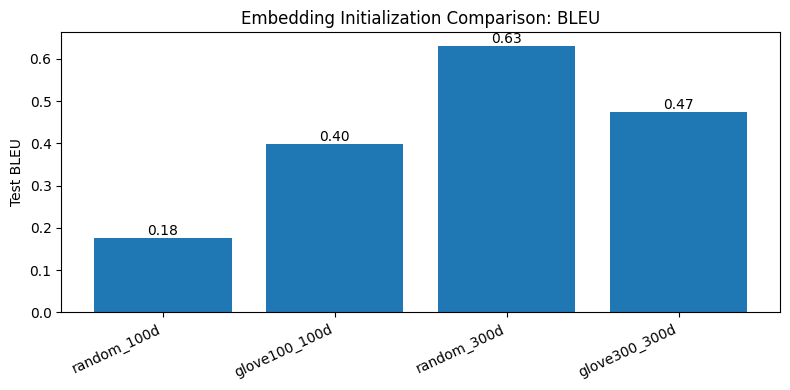

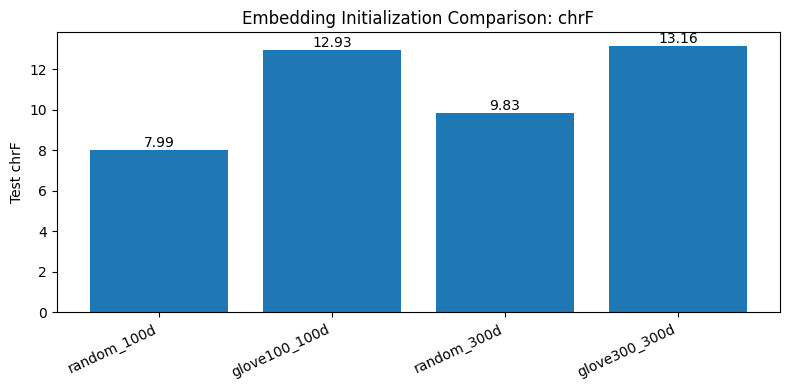

In [17]:
plot_df = embedding_results_df.copy()
plot_df["label"] = plot_df["embedding_type"] + "_" + plot_df["emb_dim"].astype(str) + "d"

plt.figure(figsize=(8, 4))
bars = plt.bar(plot_df["label"], plot_df["test_bleu"])
plt.ylabel("Test BLEU")
plt.title("Embedding Initialization Comparison: BLEU")
plt.xticks(rotation=25, ha="right")
for bar, value in zip(bars, plot_df["test_bleu"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{value:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "embedding_comparison_bleu.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
bars = plt.bar(plot_df["label"], plot_df["test_chrf"])
plt.ylabel("Test chrF")
plt.title("Embedding Initialization Comparison: chrF")
plt.xticks(rotation=25, ha="right")
for bar, value in zip(bars, plot_df["test_chrf"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{value:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "embedding_comparison_chrf.png", dpi=200)
plt.show()


## 18. Reverse translation: PT → EN


Change your input and target languages (Translate from Portuguese to English) and train your mode again o Compare the results in this step with the results from the previous step where English was the input language.

In [18]:
reverse_config = ExperimentConfig(
    name="final_word_pt_to_en_random100",
    src_lang="pt", trg_lang="en", tokenizer_type="word",
    embedding_type="random", emb_dim=100,
    hid_dim=best_hid_dim, dropout=best_dropout,
    num_epochs=FINAL_EPOCHS,
)
reverse_output = run_experiment(reverse_config, pairs, save_predictions=True, evaluate_test=True)



ExperimentConfig(name='final_word_pt_to_en_random100', src_lang='pt', trg_lang='en', tokenizer_type='word', embedding_type='random', emb_dim=100, hid_dim=512, dropout=0.3, num_epochs=5, freeze_embeddings=False)
src vocab: 18693 trg vocab: 14457
train: 19424 val: 2785 test: 5555
Epoch 01 | train loss 6.4898 | val loss 6.3231 | time 285.7s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_complete/final_word_pt_to_en_random100_best.pt
Epoch 02 | train loss 6.1325 | val loss 6.3320 | time 278.8s
Epoch 03 | train loss 5.9878 | val loss 6.3597 | time 275.9s
Epoch 04 | train loss 5.8783 | val loss 6.3046 | time 280.1s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_complete/final_word_pt_to_en_random100_best.pt
Epoch 05 | train loss 5.7941 | val loss 6.2793 | time 279.0s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_complete/final_word_pt_to_en_random100_best.pt
Test BLEU: 0.91 Test chrF: 12.77


## 19. Character-level EN → PT model

Develop a character-based model that trains to translate characters into the target language.  
Compare the results by this model with the achieved results from the word-based models before.

In [19]:
char_config = ExperimentConfig(
    name="final_char_en_to_pt_random",
    src_lang="en",
    trg_lang="pt",
    tokenizer_type="char",
    embedding_type="random",
    emb_dim=128,
    hid_dim=256,
    dropout=best_dropout,
    num_epochs=CHAR_EPOCHS
)
char_output = run_experiment(char_config, pairs, save_predictions=True)


ExperimentConfig(name='final_char_en_to_pt_random', src_lang='en', trg_lang='pt', tokenizer_type='char', embedding_type='random', emb_dim=128, hid_dim=256, dropout=0.3, num_epochs=3, freeze_embeddings=False)
src vocab: 119 trg vocab: 118
train: 17572 val: 2493 test: 5006
Epoch 01 | train loss 2.7871 | val loss 3.0343 | time 108.0s
Saved best model: /Users/baturu/Desktop/machine_translation/outputs_task3_complete/final_char_en_to_pt_random_best.pt
Epoch 02 | train loss 2.5888 | val loss 3.0661 | time 114.9s
Epoch 03 | train loss 2.5420 | val loss 3.0671 | time 114.1s
Test BLEU: 1.25 Test chrF: 4.92


## 20. Final results summary

In [20]:
all_outputs = embedding_outputs + [reverse_output, char_output]
final_results_df = pd.DataFrame([output["result"] for output in all_outputs if output is not None])

display(final_results_df[[
    "name", "src_lang", "trg_lang", "tokenizer_type", "embedding_type",
    "emb_dim", "hid_dim", "dropout", "src_embedding_coverage",
    "trg_embedding_coverage", "best_val_loss", "test_bleu", "test_chrf",
]])
final_results_df.to_csv(OUTPUT_DIR / "final_task3_results_summary.csv", index=False)


,name,src_lang,trg_lang,tokenizer_type,embedding_type,emb_dim,hid_dim,dropout,src_embedding_coverage,trg_embedding_coverage,best_val_loss,test_bleu,test_chrf
0,final_word_en_to_pt_random100,en,pt,word,random,100,512,0.3,0.000000,0.0,6.457129,0.175463,7.990387
1,final_word_en_to_pt_glove100,en,pt,word,glove100,100,512,0.3,0.630181,0.0,6.353396,0.399098,12.928489
2,final_word_en_to_pt_random300,en,pt,word,random,300,512,0.3,0.000000,0.0,6.340412,0.631275,9.826403
3,final_word_en_to_pt_glove300,en,pt,word,glove300,300,512,0.3,0.630181,0.0,6.363624,0.473373,13.155343
4,final_word_pt_to_en_random100,pt,en,word,random,100,512,0.3,0.000000,0.0,6.279320,0.906851,12.766654
5,final_char_en_to_pt_random,en,pt,char,random,128,256,0.3,0.000000,0.0,3.034343,1.247487,4.918199


## 21. Embedding impact comparison

In [21]:
embedding_comparison_df = embedding_results_df.copy()
display(embedding_comparison_df[[
    "name", "embedding_type", "emb_dim", "src_embedding_coverage",
    "best_val_loss", "test_bleu", "test_chrf",
]])


,name,embedding_type,emb_dim,src_embedding_coverage,best_val_loss,test_bleu,test_chrf
0,final_word_en_to_pt_random100,random,100,0.000000,6.457129,0.175463,7.990387
1,final_word_en_to_pt_glove100,glove100,100,0.630181,6.353396,0.399098,12.928489
2,final_word_en_to_pt_random300,random,300,0.000000,6.340412,0.631275,9.826403
3,final_word_en_to_pt_glove300,glove300,300,0.630181,6.363624,0.473373,13.155343


## 22. Direction comparison: EN → PT vs PT → EN

In [22]:
direction_comparison_df = final_results_df[
    final_results_df["name"].isin([
        "final_word_en_to_pt_random100",
        "final_word_pt_to_en_random100",
    ])
].copy()

display(direction_comparison_df[[
    "name", "src_lang", "trg_lang", "emb_dim", "test_bleu", "test_chrf"
]])
direction_comparison_df.to_csv(OUTPUT_DIR / "translation_direction_comparison.csv", index=False)



,name,src_lang,trg_lang,emb_dim,test_bleu,test_chrf
0,final_word_en_to_pt_random100,en,pt,100,0.175463,7.990387
4,final_word_pt_to_en_random100,pt,en,100,0.906851,12.766654


## 23. Word-level vs character-level comparison

In [23]:
level_comparison_df = final_results_df[
    final_results_df["name"].isin([
        "final_word_en_to_pt_random100",
        "final_char_en_to_pt_random",
    ])
].copy()

display(level_comparison_df[[
    "name", "tokenizer_type", "emb_dim", "test_bleu", "test_chrf"
]])
level_comparison_df.to_csv(OUTPUT_DIR / "word_vs_character_comparison.csv", index=False)



,name,tokenizer_type,emb_dim,test_bleu,test_chrf
0,final_word_en_to_pt_random100,word,100,0.175463,7.990387
5,final_char_en_to_pt_random,char,128,1.247487,4.918199


## 24. Qualitative translation examples

In [24]:
if final_random_output is not None:
    model = final_random_output["model"]
    src_vocab = final_random_output["src_vocab"]
    trg_vocab = final_random_output["trg_vocab"]
    test_data = final_random_output["test_data"]

    for i in range(5):
        src, ref = test_data.examples[i]
        hyp = " ".join(translate_sentence(model, src, src_vocab, trg_vocab, max_output_len=80))
        print(f"Example {i+1}")
        print("SRC:", src)
        print("REF:", ref)
        print("HYP:", hyp)
        print("-" * 80)

Example 1
SRC: it is not sufficient to devote significant sums to decommissioning outdated power stations - we must also pay attention to maintaining them.
REF: não é suficiente destinar somas significativas para o desmantelamento das centrais ultrapassadas; temos também de prestar atenção à sua manutenção.
HYP: a que de que a <unk> de <unk>
--------------------------------------------------------------------------------
Example 2
SRC: i would ask these same member states to introduce legislative measures to promote gender balance in positions of responsibility, especially in private companies.
REF: solicitaria a esses mesmos estados-membros que introduzissem medidas legislativas de promoção do equilíbrio de género nas posições de responsabilidade, especialmente em companhias privadas.
HYP: o que de <unk> <unk> <unk>
--------------------------------------------------------------------------------
Example 3
SRC: it is suffering from the external costs of the crisis, by which i mean that

## 25. Sentence length impact analysis

,src_length,chrf
count,300.000000,300.000000
mean,22.793333,7.975380
std,10.422703,4.438919
min,2.000000,1.347386
25%,15.000000,4.820078
50%,22.000000,7.546403
75%,30.000000,9.761438
max,48.000000,29.393038


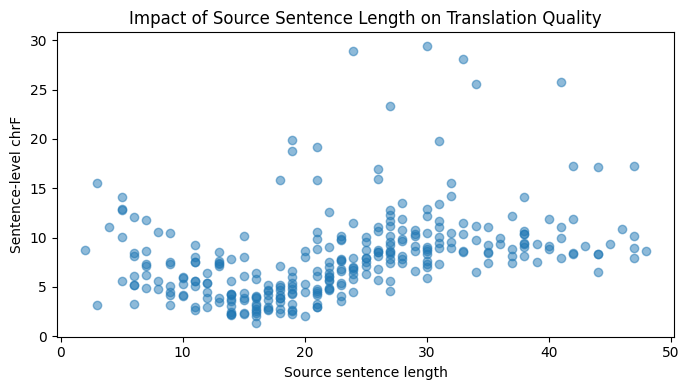

In [25]:
if final_random_output is not None:
    model = final_random_output["model"]
    src_vocab = final_random_output["src_vocab"]
    trg_vocab = final_random_output["trg_vocab"]
    test_data = final_random_output["test_data"]

    rows = []
    for src, ref in test_data.examples[:300]:
        hyp = " ".join(translate_sentence(model, src, src_vocab, trg_vocab, max_output_len=80))
        rows.append({
            "src_length": len(word_tokenize(src)),
            "chrf": sentence_chrf(ref, hyp),
            "src": src,
            "ref": ref,
            "hyp": hyp
        })

    length_impact_df = pd.DataFrame(rows)
    display(length_impact_df[["src_length", "chrf"]].describe())

    plt.figure(figsize=(7, 4))
    plt.scatter(length_impact_df["src_length"], length_impact_df["chrf"], alpha=0.5)
    plt.xlabel("Source sentence length")
    plt.ylabel("Sentence-level chrF")
    plt.title("Impact of Source Sentence Length on Translation Quality")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "length_vs_chrf.png", dpi=200)
    plt.show()

    length_impact_df.to_csv(OUTPUT_DIR / "length_impact_analysis.csv", index=False)

## 26. Report text templates

### Hyperparameter tuning

> We performed manual hyperparameter tuning using the validation set. Three configurations were compared by varying the embedding dimension, LSTM hidden dimension, and dropout rate. Each configuration was trained for a small number of epochs, and the configuration with the lowest validation loss was selected for the final experiments. Manual tuning was chosen instead of exhaustive grid search because neural machine translation training is computationally expensive.

### Embedding comparison

> To analyze the impact of different embedding models, we compared randomly initialized embeddings with pretrained GloVe embeddings. Random embeddings were learned from scratch during model training, while GloVe initialized the embedding layers with pretrained word vectors. The models were compared using validation loss, BLEU, and chrF.

### Encoder-decoder architecture

> The model is an RNN-based sequence-to-sequence architecture with an LSTM encoder and an LSTM decoder. The encoder maps the source sentence into hidden and cell states. These states initialize the decoder, which generates the target sentence token by token. Teacher forcing was used during training.

### Direction and character-level comparison

> We trained the model for both English-to-Portuguese and Portuguese-to-English translation. We also trained a character-level model in which the vocabulary consists of characters instead of words. This allows a comparison between word-level and character-level translation under the same encoder-decoder framework.